# Exploratory Data Analysis and Preprocessing
This notebook explores the **Human Activity Recognition (HAR)** feature dataset (561 engineered sensor features per window) and performs:

- **Data loading** (features, train split, subject IDs, activity labels)
- **Basic EDA** (dataset size, label list, missing-value checks, class/subject distributions)
- **Feature preprocessing** (standardization)
- **Dimensionality reduction with PCA** (2D/3D projections + explained variance)
- **Label encoding** (preparing labels for downstream ML models)

## Dataset expectation
The file paths (e.g., `../data/train/X_train.txt`) match the common UCI HAR directory layout. `X_train.txt` contains the numeric feature vectors; `y_train.txt` contains integer activity IDs; `subject_train.txt` indicates which participant generated each sample.


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import os
import plotly.express as px


In [2]:
# Reproducibility for shuffling
RANDOM_SEED = 123

## EDA (Exploratory Data Analysis)

Analyze the data splits and investigate the following items.
- sensor signals (accelerometer + gyroscope)
- number of samples / features
- activity labels and classes
- dataset description & feature list
- class distribution and potential imbalance
- comparison of class distribution between **train** and **test**.
### Train Split

In [3]:
# Load dataset metadata and training split
# - `features.txt`: maps 1..561 -> feature name
# - `X_train.txt`: feature matrix (rows=samples, cols=features)
# - `y_train.txt`: activity ID per sample (integer labels)
# - `subject_train.txt`: subject ID per sample
# - `activity_labels.txt`: maps activity ID -> human-readable activity name
features = pd.read_csv('../data/features.txt', sep='\s+', header=None, names=['index', 'feature_name'])

X = pd.read_csv('../data/train/X_train.txt', sep='\s+', header=None)
y = pd.read_csv('../data/train/y_train.txt', sep='\s+', header=None, names=['activity'])

subjects = pd.read_csv('../data/train/subject_train.txt', sep='\s+', header=None, names=['subject'])
activity_labels = pd.read_csv('../data/activity_labels.txt', sep='\s+', header=None, names=['index', 'activity_name'])

## Train dataset 
We confirm:
- the shape of `X` (samples × features)
- the list of activity labels available in the dataset
- that there are **no missing values** in the training split


In [4]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Activity labels:\n\n", activity_labels.activity_name.to_string(index=False))
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum().sum())
print("Missing values in subjects:", subjects.isnull().sum().sum())

Number of samples: 7352
Number of features: 561
Activity labels:

            WALKING
  WALKING_UPSTAIRS
WALKING_DOWNSTAIRS
           SITTING
          STANDING
            LAYING
Missing values in X: 0
Missing values in y: 0
Missing values in subjects: 0


#### Class and subject distribution
These plots help detect **class imbalance** (some activities much more common) and **subject imbalance** (some subjects contributing many more windows).



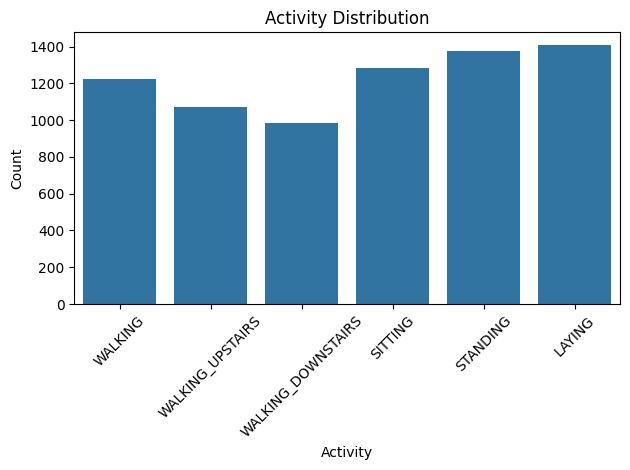

activity
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [5]:
activity_counts = y['activity'].value_counts().sort_index()

plt.figure()
sns.barplot(x=activity_labels.activity_name, y=activity_counts.values)

plt.title("Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(activity_counts)

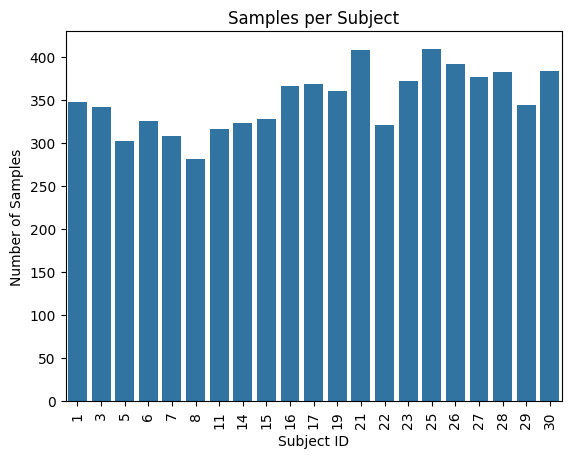

subject
1     347
3     341
5     302
6     325
7     308
8     281
11    316
14    323
15    328
16    366
17    368
19    360
21    408
22    321
23    372
25    409
26    392
27    376
28    382
29    344
30    383
Name: count, dtype: int64


In [6]:
subject_counts = subjects['subject'].value_counts().sort_index()

plt.figure()
sns.barplot(x=subject_counts.index, y=subject_counts.values)

plt.title("Samples per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.show()

print(subject_counts)

### Test Split


In [7]:
# Load test split (pre-computed feature vectors)
X_test = pd.read_csv('../data/test/X_test.txt', sep='\\s+', header=None)
y_test = pd.read_csv('../data/test/y_test.txt', sep='\\s+', header=None, names=['activity'])
subjects_test = pd.read_csv('../data/test/subject_test.txt', sep='\\s+', header=None, names=['subject'])

print("Test shape (samples, features):", X_test.shape)
print("Train shape (samples, features):", X.shape)

print("Test missing values in X_test:", X_test.isnull().sum().sum())
print("Test missing values in y_test:", y_test.isnull().sum().sum())
print("Test missing values in subjects_test:", subjects_test.isnull().sum().sum())

Test shape (samples, features): (2947, 561)
Train shape (samples, features): (7352, 561)
Test missing values in X_test: 0
Test missing values in y_test: 0
Test missing values in subjects_test: 0


#### Test activity label set
We verify that the set of activity IDs present in the test split matches the global `activity_labels` table (and implicitly the train split).


In [8]:
train_ids = set(y['activity'].unique())
test_ids = set(y_test['activity'].unique())
all_ids = set(activity_labels['index'])

print("Train activity IDs:", sorted(train_ids))
print("Test activity IDs:", sorted(test_ids))
print("All label IDs:", sorted(all_ids))

print("Test IDs subset of label IDs?", test_ids.issubset(all_ids))
print("Test IDs subset of train IDs?", test_ids.issubset(train_ids))

Train activity IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Test activity IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
All label IDs: [1, 2, 3, 4, 5, 6]
Test IDs subset of label IDs? True
Test IDs subset of train IDs? True


### Class Distribution in Test vs Train
These plots help check for **class imbalance** and **distribution shift** between train and test.


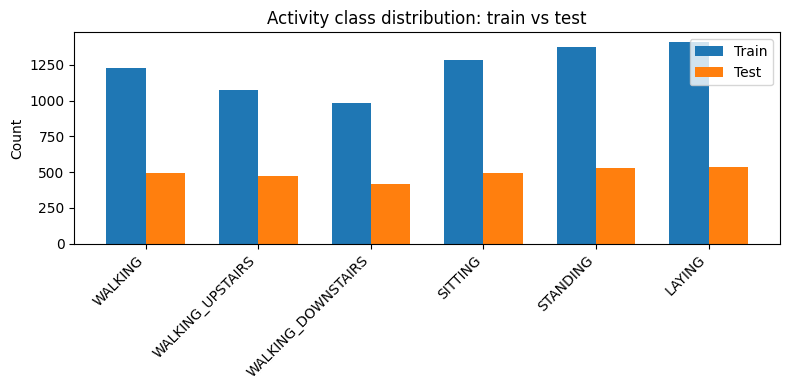

,activity_id,train_count,test_count,index,activity_name
0,1,1226,496,1,WALKING
1,2,1073,471,2,WALKING_UPSTAIRS
2,3,986,420,3,WALKING_DOWNSTAIRS
3,4,1286,491,4,SITTING
4,5,1374,532,5,STANDING
5,6,1407,537,6,LAYING


In [9]:
# Per-class counts in train and test
train_counts = y['activity'].value_counts().sort_index()
test_counts = y_test['activity'].value_counts().sort_index()

# Merge into a single DataFrame for easier plotting
class_dist = pd.DataFrame({
    'activity_id': train_counts.index,
    'train_count': train_counts.values,
    'test_count': test_counts.reindex(train_counts.index).fillna(0).values,
})

class_dist = class_dist.merge(activity_labels, left_on='activity_id', right_on='index')

plt.figure(figsize=(8,4))
width = 0.35
x = np.arange(len(class_dist))

plt.bar(x - width/2, class_dist['train_count'], width=width, label='Train')
plt.bar(x + width/2, class_dist['test_count'],  width=width, label='Test')

plt.xticks(x, class_dist['activity_name'], rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Activity class distribution: train vs test')
plt.legend()
plt.tight_layout()
plt.show()

class_dist

The graph above shows a consistent label distribution between the training and test sets. Also, since there are no anomalies or missing data in the splits, we will use these original splits for model training and testing after some potential preprocessing.

#### Sensor Signals and Sampling Frequency (Test Set)

The original features are derived from raw **accelerometer** and **gyroscope** 3-axial signals:

- Raw time-domain signals: `tAcc-XYZ`, `tGyro-XYZ` (and derived body/gravity/jerk/magnitude variants).
- Sampling frequency: **50 Hz** (from `features_info.txt`).
- Windowing: sliding windows of 2.56 s (128 readings per window) with 50% overlap.

Below we load a couple of inertial-signal files and plot example windows for a chosen subject + activity.


Plotting Sample Test Inertial Signals
Inertial acc_x shape (windows, samples_per_window): (2947, 128)
Inertial gyro_x shape (windows, samples_per_window): (2947, 128)


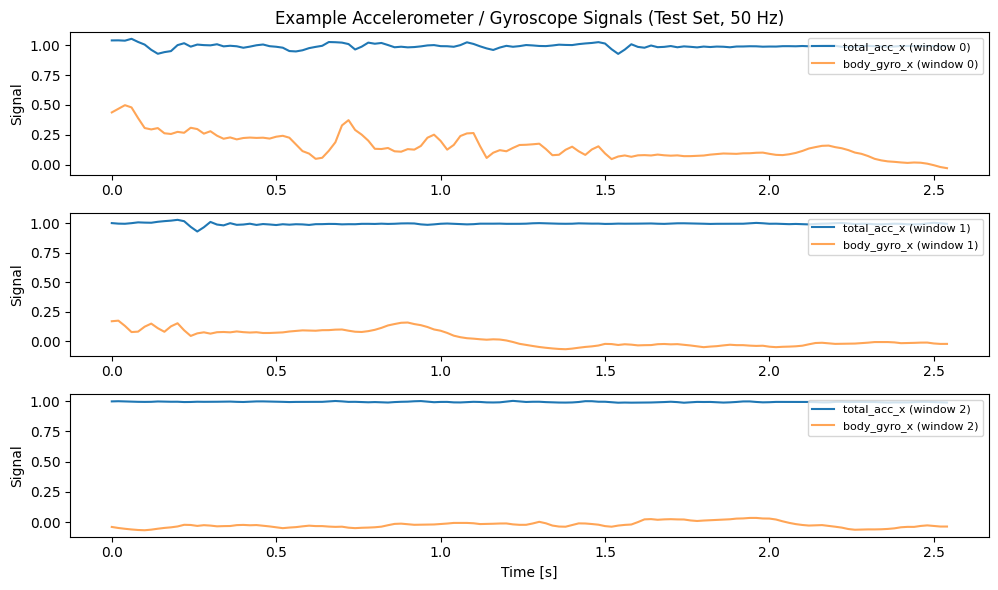

Plotting Sample Train Inertial Signals
Inertial acc_x shape (windows, samples_per_window): (7352, 128)
Inertial gyro_x shape (windows, samples_per_window): (7352, 128)


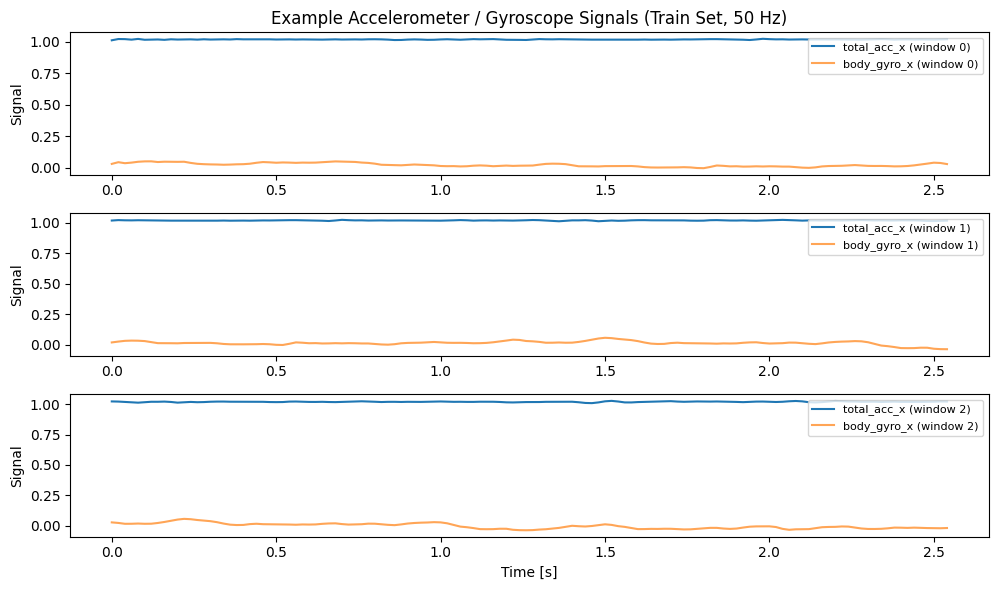

In [10]:
def plot_inertial_signals(files_dir: str, data_type: str):
    print(f"Plotting Sample {data_type.lower().title()} Inertial Signals")
    # Example inertial files (accelerometer + gyroscope, X axis)
    acc_x_path = os.path.join(files_dir, f'total_acc_x_{data_type.lower()}.txt')
    gyro_x_path = os.path.join(files_dir, f'body_gyro_x_{data_type.lower()}.txt')

    # Each row corresponds to a window; each column to a 1/50s sample within that window
    acc_x = np.loadtxt(acc_x_path)
    gyro_x = np.loadtxt(gyro_x_path)

    print('Inertial acc_x shape (windows, samples_per_window):', acc_x.shape)
    print('Inertial gyro_x shape (windows, samples_per_window):', gyro_x.shape)

    fs = 50.0  # Hz (from dataset description)
    t = np.arange(acc_x.shape[1]) / fs

    # Plot a few example windows
    n_examples = 3
    plt.figure(figsize=(10,6))
    for i in range(n_examples):
        plt.subplot(n_examples, 1, i+1)
        plt.plot(t, acc_x[i], label='total_acc_x (window %d)' % i)
        plt.plot(t, gyro_x[i], label='body_gyro_x (window %d)' % i, alpha=0.7)
        plt.ylabel('Signal')
        if i == 0:
            plt.title(f'Example Accelerometer / Gyroscope Signals ({data_type.lower().title()} Set, 50 Hz)')
        if i == n_examples-1:
            plt.xlabel('Time [s]')
        plt.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

INERTIAL_TEST_DIR = '../data/test/Inertial Signals'
INERTIAL_TRAIN_DIR = '../data/train/Inertial Signals'
for (data_type, files_dir) in [('Test', INERTIAL_TEST_DIR), ('Train', INERTIAL_TRAIN_DIR)]:
    plot_inertial_signals(files_dir, data_type)

## PCA (Dimensionality Reduction)

PCA projects the 561-dimensional feature vectors into a low-dimensional space to:
- visualize whether activities cluster/separate
- estimate how many components are needed to retain most variance


We **standardize** features before PCA because features may be on different scales; PCA is scale-sensitive.


In [ ]:
# Reset indices after shuffling so `X` and `y` align cleanly by row index
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Standardize features (mean=0, std=1) before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Explore Projection on 2 and 3 Dimensions

In [ ]:
# Fit PCA and project into 2 principal components for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Assemble a plotting-friendly dataframe
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['activity'] = y.activity

In [12]:
activity_map = {}
for i, name in enumerate(activity_labels.activity_name):
    activity_map[i+1] = name

pca_df['activity_name'] = pca_df['activity'].map(activity_map)

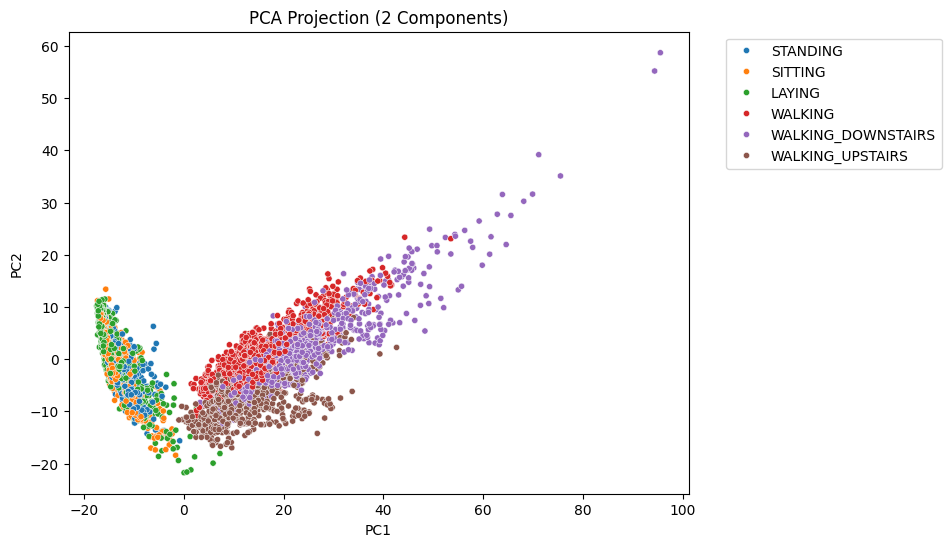

In [13]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='activity_name',
    data=pca_df,
    palette='tab10',
    s=20
)

plt.title("PCA Projection (2 Components)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

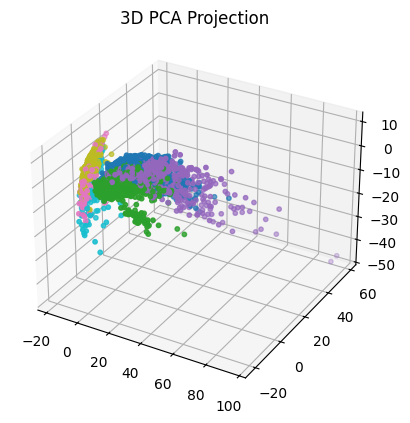

In [14]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=y['activity'],
    cmap='tab10',
    s=10
)

ax.set_title("3D PCA Projection")
plt.show()

In [ ]:
pca_df_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['activity'] = pca_df['activity_name']  # use names

fig = px.scatter_3d(
    pca_df_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='activity',
    title='Interactive 3D PCA Projection'
)

fig.show()

Since the data does not seem to be linearly separable in 2D or 3D, we explore higher dimensions in the next section. 

### Choosing Number of Components
Two common ways shown below:

- **Target variance (e.g., 99%)**: choose the smallest number of PCs whose cumulative explained variance ≥ 0.99.
- **Explained-variance curve**: visualize the “elbow” and how quickly variance accumulates.


In [21]:
# Pick the smallest number of PCs that retains ~99% of variance
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print("Number of components selected (99% variance):", pca.n_components_)

Number of components selected (99% variance): 63


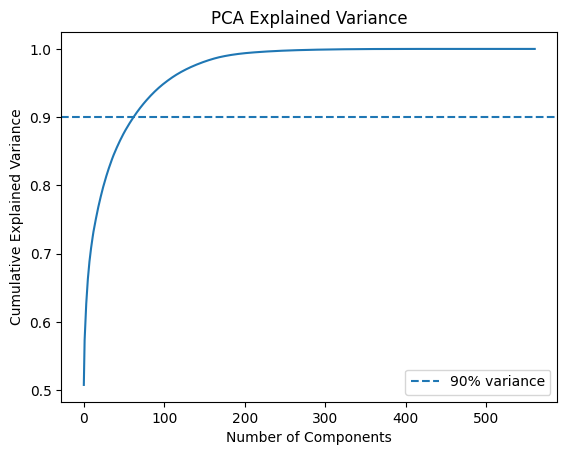

In [22]:
# Visualize how variance accumulates as we add more components
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(cum_var)
plt.axhline(y=0.90, linestyle='--', label='90% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

The results and graph above show that 90% of the variance can be retained with less than 100 components. That means there's a compact representation of the data that captures most useful information.

## Preprocessing: TODO (To be completed later)

In [18]:
X, y, subjects = shuffle(X, y, subjects, random_state=RANDOM_SEED)

### Label encoding
Many ML libraries expect class labels as 0..(K-1) integers. This converts the activity IDs into a contiguous integer encoding suitable for classifiers.


In [19]:
# Encode labels to 0..K-1
# Note: `y['activity']` is already numeric, but LabelEncoder ensures a contiguous encoding.
le = LabelEncoder()
y_encoded = le.fit_transform(y['activity'])

y_encoded

array([4, 0, 4, ..., 3, 4, 1], shape=(7352,))